In [1]:
from pathlib import Path
from collections import defaultdict

ROOT = Path(".")

SKIP_DIRS = {"data", "output"}
SKIP_FILES = {"ieee.csl"}
SKIP_EXTS = {
    ".pdf", ".png", ".jpg", ".jpeg", ".gif", ".webp", ".zip", ".gz", ".tar", ".7z",
    ".mp4", ".mp3", ".wav", ".bin", ".so", ".o", ".pyc", ".npy", ".npz"
}

CODE = {
    "batch_train.py", "compress.py", "mobile_benchmark.py", "mobile_export.py",
    "presentation", "render.py", "scene", "setup.py", "utils", "writeup", "scripts"
}

COLORS = {
    ".py": "#9ecae1",
    ".cu": "#fdae6b",
    ".cpp": "#c7e9c0",
    ".h": "#c6dbef",
    ".hpp": "#dadaeb",
    ".sh": "#fdd0a2",
    ".md": "#d9d9d9",
    ".txt": "#f0f0f0",
    ".json": "#bcbddc",
    ".yaml": "#b3cde3",
    ".yml": "#b3cde3",
}

PAD_GROUP = 1.0
PAD_FILE = 0.18


def is_binary(p):
    try:
        return b"\0" in p.read_bytes()[:4096]
    except Exception:
        return True


def count_lines(p):
    try:
        return sum(1 for _ in p.open("r", encoding="utf-8", errors="ignore"))
    except Exception:
        return 0


def code_owner(p):
    rel = p.relative_to(ROOT)
    top = rel.parts[0]

    if top in CODE:
        return top

    if p.name in CODE:
        return p.name

    return None


groups = defaultdict(list)

for p in ROOT.rglob("*"):
    if not p.is_file():
        continue

    if p.name in SKIP_FILES:
        continue

    if any(part in SKIP_DIRS for part in p.parts):
        continue

    if p.suffix.lower() in SKIP_EXTS or is_binary(p):
        continue

    owner = code_owner(p)
    if not owner:
        continue

    n = count_lines(p)
    if n:
        groups[owner].append((p, n))


totals = {g: sum(n for _, n in files) for g, files in groups.items()}
items = sorted(totals.items(), key=lambda x: x[1], reverse=True)

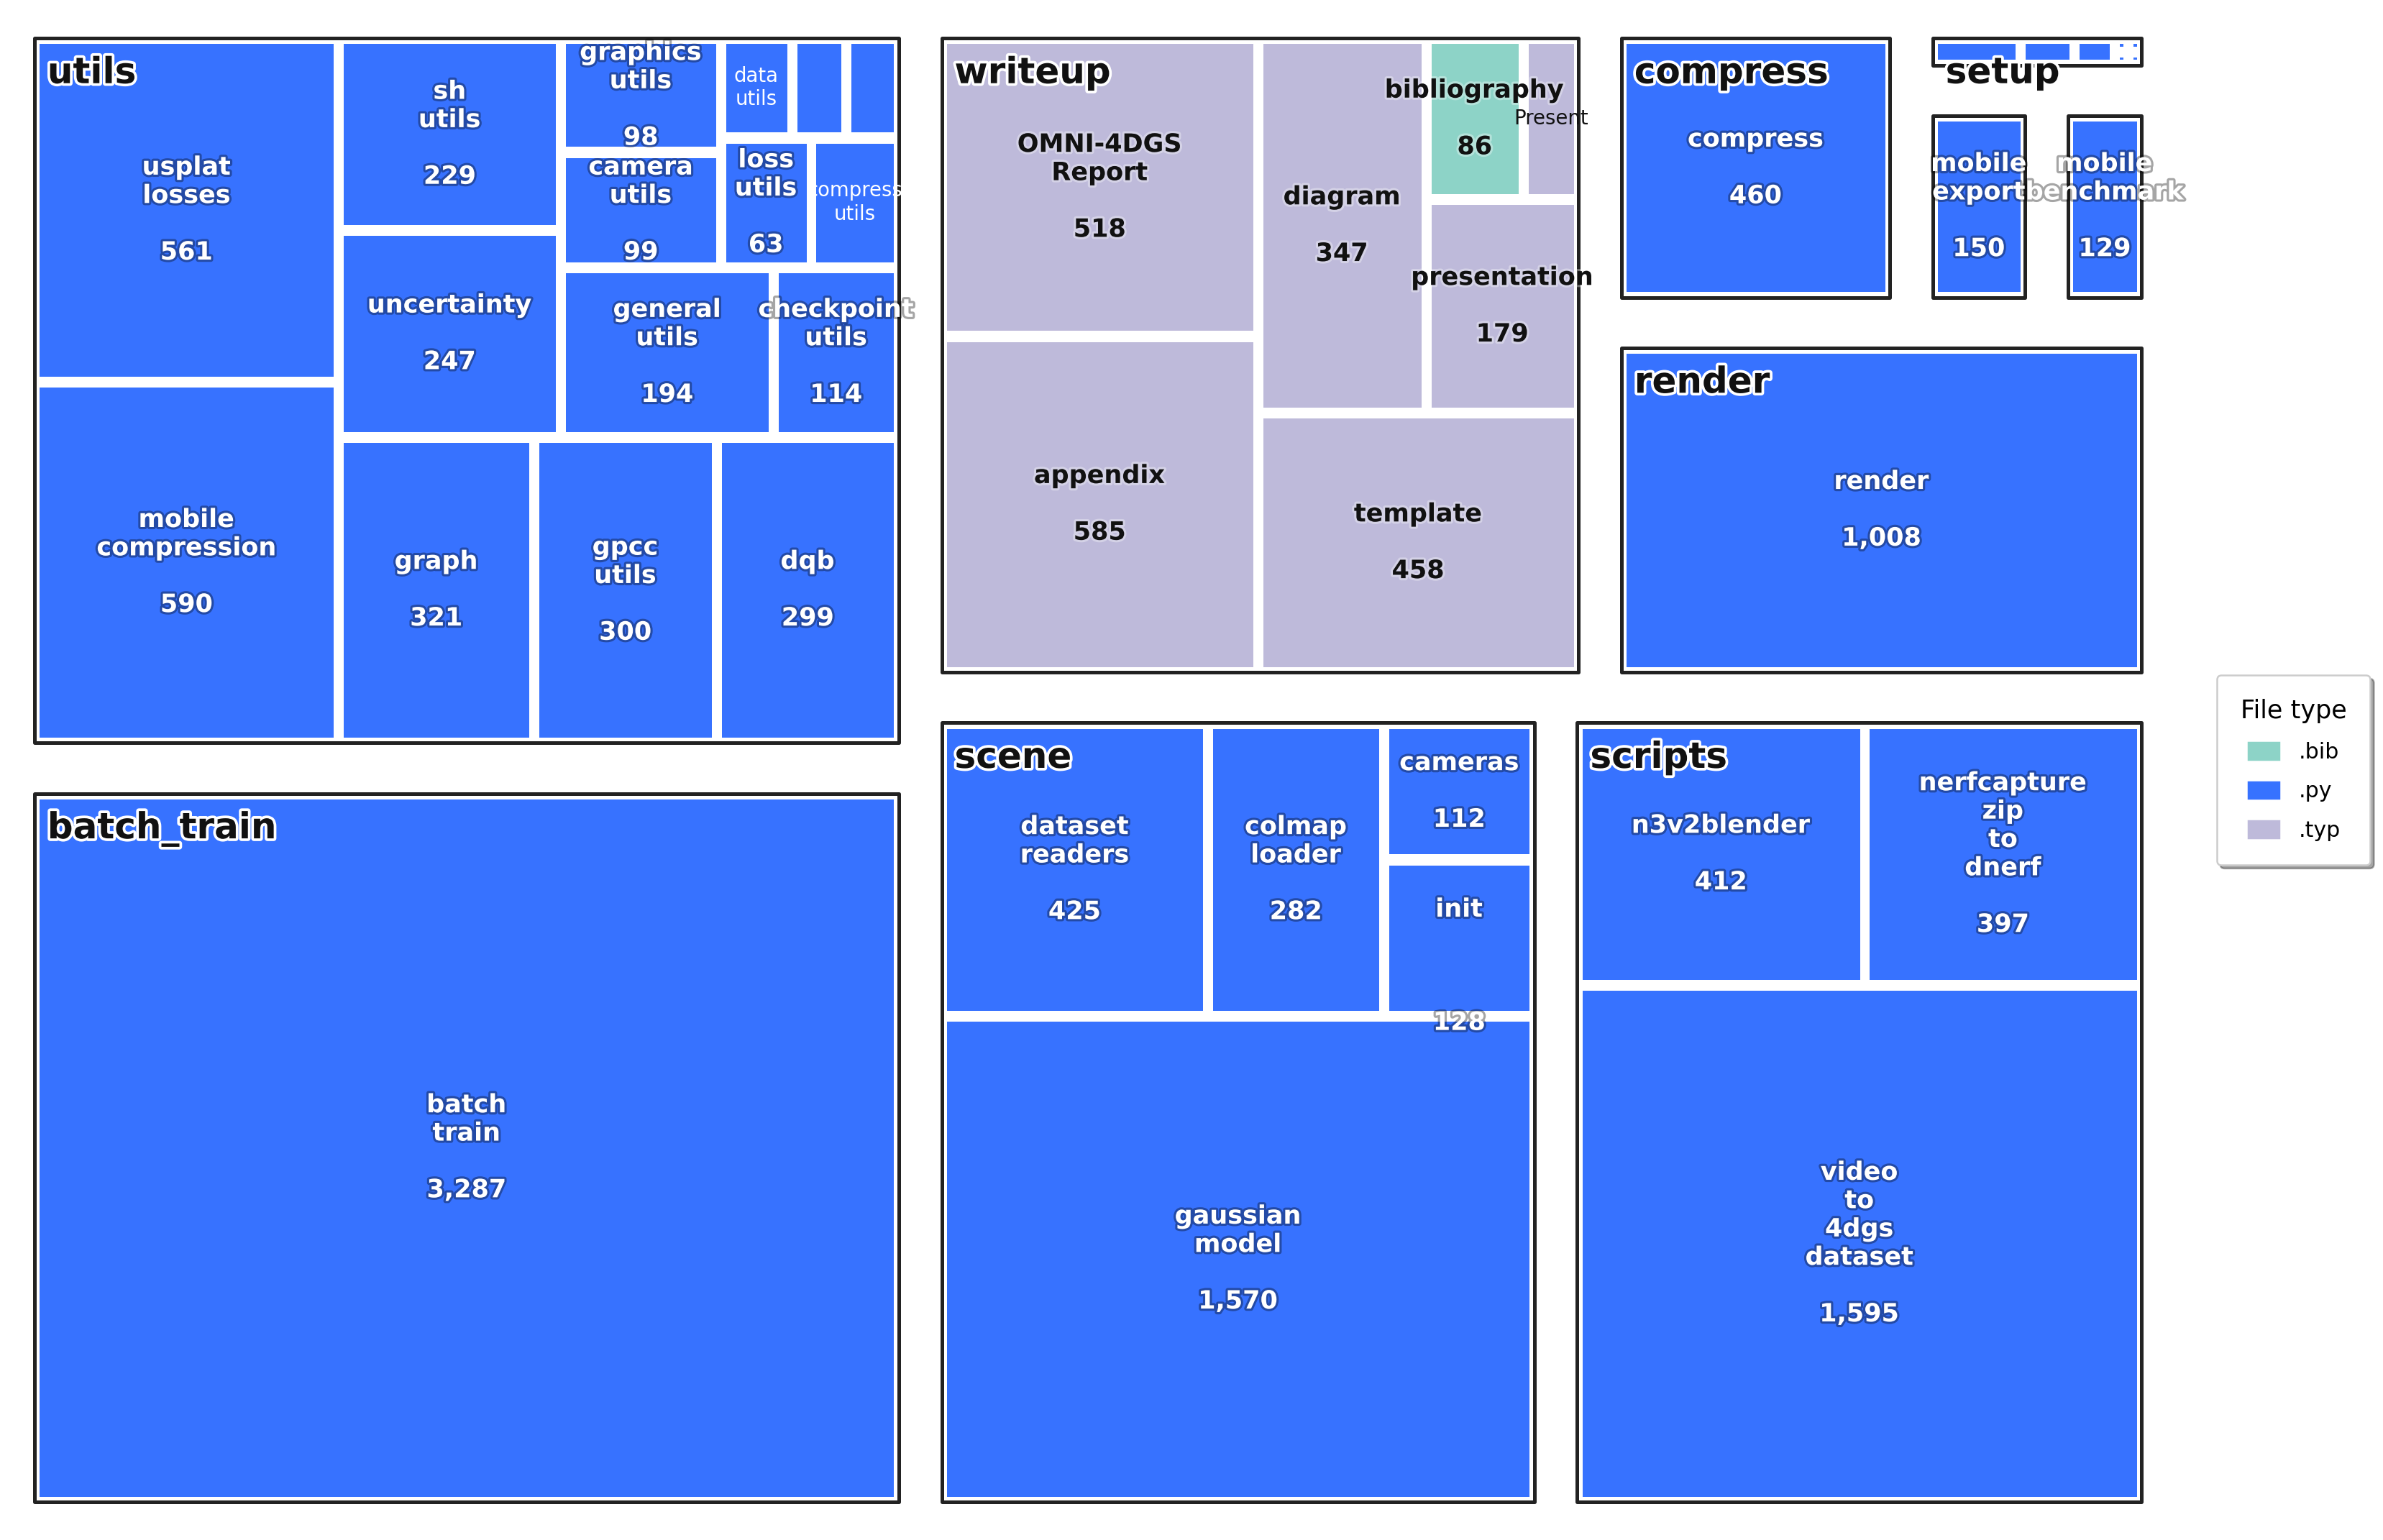

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle, Patch
import matplotlib.colors as mcolors
from pathlib import Path
import squarify

# Larger, cleaner defaults
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 22,
    "legend.fontsize": 12,
    "legend.title_fontsize": 14,
    "svg.fonttype": "none",   # editable text in SVG
})

fig, ax = plt.subplots(figsize=(22, 13), dpi=180)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

ax.set_xlim(0, 100)
ax.set_ylim(0, 60)
ax.axis("off")

def remove_extension(name):
    name = str(name)
    suffix = Path(name).suffix
    return name[:-len(suffix)] if suffix else name

# Build a vibrant color map for observed extensions
all_exts = sorted({
    (p.suffix.lower() or "[none]")
    for group, _ in items
    for p, _ in groups[group]
})

palette = (
    list(plt.cm.Set3.colors) +
    list(plt.cm.tab20.colors) +
    list(plt.cm.Dark2.colors) +
    list(plt.cm.Paired.colors)
)

EXT_COLORS = {
    ext: mcolors.to_hex(palette[i % len(palette)])
    for i, ext in enumerate(all_exts)
}

EXT_COLORS.update({
    ".py": "#3772ff",
    ".js": "#f7df1e",
    ".ts": "#3178c6",
    ".json": "#00b894",
    ".md": "#9b5de5",
    ".html": "#ff6b35",
    ".css": "#00bbf9",
    ".txt": "#adb5bd",
    "[none]": "#ced4da",
})

def text_color(bg):
    r, g, b = mcolors.to_rgb(bg)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "#111111" if luminance > 0.62 else "white"

rects = squarify.squarify(
    squarify.normalize_sizes([v for _, v in items], 100, 60),
    0, 0, 100, 60
)

used_exts = set()

for (group, total), r in zip(items, rects):
    x = r["x"] + PAD_GROUP
    y = r["y"] + PAD_GROUP
    w = max(r["dx"] - 2 * PAD_GROUP, 0)
    h = max(r["dy"] - 2 * PAD_GROUP, 0)

    ax.add_patch(Rectangle(
        (x, y), w, h,
        fill=False,
        edgecolor="#222222",
        linewidth=2.0,
        joinstyle="round"
    ))

    # Group title without extension
    group_title = remove_extension(group)

    # Hide titles that start with "mobile"
    if not group_title.lower().startswith("mobile"):
        ax.text(
            x + 0.6,
            y + h - 0.7,
            group_title,
            ha="left",
            va="top",
            fontsize=20,
            weight="bold",
            color="#111111",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")]
        )

    files = sorted(groups[group], key=lambda x: x[1], reverse=True)

    sub_rects = squarify.squarify(
        squarify.normalize_sizes([n for _, n in files], max(w, 0.1), max(h, 0.1)),
        x, y, max(w, 0.1), max(h, 0.1)
    )

    for (p, n), sr in zip(files, sub_rects):
        sx = sr["x"] + PAD_FILE
        sy = sr["y"] + PAD_FILE
        sw = max(sr["dx"] - 2 * PAD_FILE, 0)
        sh = max(sr["dy"] - 2 * PAD_FILE, 0)

        ext = p.suffix.lower() or "[none]"
        color = EXT_COLORS.get(ext, "#eeeeee")
        used_exts.add(ext)

        ax.add_patch(Rectangle(
            (sx, sy), sw, sh,
            facecolor=color,
            edgecolor="#ffffff",
            linewidth=1.2
        ))

        area = sw * sh

        # Remove file extension, then split underscores into new lines
        display_name = remove_extension(p.name)
        display_name = display_name.replace("_", "\n")

        if area > 18:
            label = f"{display_name}\n\n{n:,}"

            ax.text(
                sx + sw / 2,
                sy + sh / 2,
                label,
                ha="center",
                va="center",
                fontsize=14,
                weight="semibold",
                color=text_color(color),
                wrap=True,
                path_effects=[
                    pe.withStroke(
                        linewidth=2.5,
                        foreground="black" if text_color(color) == "white" else "white",
                        alpha=0.35
                    )
                ]
            )

        elif area > 9:
            ax.text(
                sx + sw / 2,
                sy + sh / 2,
                display_name,
                ha="center",
                va="center",
                fontsize=11,
                weight="medium",
                color=text_color(color),
                wrap=True
            )

legend = [
    Patch(facecolor=EXT_COLORS.get(ext, "#eeeeee"), edgecolor="white", label=ext)
    for ext in sorted(used_exts)
]

fig.subplots_adjust(left=0.025, right=0.78, top=0.94, bottom=0.04)

ax.legend(
    handles=legend,
    title="File type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=1.1,
    labelspacing=0.8,
    handlelength=1.6,
    handleheight=1.1
)

plt.show()

# Optional save with transparent background:
# plt.savefig("treemap.svg", transparent=True, bbox_inches="tight")
# plt.savefig("treemap.png", transparent=True, bbox_inches="tight", dpi=300)